## Dependencies


In [ ]:
import pandas as pd
import numpy as np
import json
import pandas as pd
import os
import re
import glob
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  
import ast 
from pathlib import Path
import sys 
import ast
from statsmodels.stats.multitest import multipletests

# Custom functions
from multiple_test import analyze_results, create_heatmap, create_bar_plot

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd() # Assumes the notebook is launched from the repository root
# REPO_ROOT = Path.cwd().parents[1]
# sys.path.insert(0, str(REPO_ROOT))

FIGURE_PATH = REPO_ROOT / "dat" / "figures" # Put your figure directory

In [102]:
cut_off = 500 # Sample size threshold 

colors = {
    # GPT-4 family (Teal shades)
    'GPT-4-0314_mid_DAT': '#008080',
    'GPT-4-0314_mid_control': '#66CCCC',
    'GPT-4-turbo_mid_DAT': '#008080',
    'GPT-4-turbo_mid_control': '#66CCCC',
    'GPT-4-turbo-0125_mid_DAT': '#008080',
    'GPT-4-turbo-0125_mid_control': '#66CCCC',
    'GPT-4.5-preview_mid_DAT': '#008080',
    'GPT-4.5-preview_mid_control': '#66CCCC',
    'GPT-4o-mini_mid_DAT': '#008080',
    'GPT-4o-mini_mid_control': '#66CCCC',
    'GPT-3.5-turbo_mid_DAT': '#008080',
    'GPT-3.5-turbo_mid_control': '#66CCCC',

    # Claude family (Orange shades)
    'Claude3-opus_mid_DAT': '#FF8C00',
    'Claude3-opus_mid_control': '#FFD39B',
    'Claude3.5-haiku_mid_DAT': '#FF8C00',
    'Claude3.5-haiku_mid_control': '#FFD39B',
    'Claude3.7-sonnet_mid_DAT': '#FF8C00',
    'Claude3.7-sonnet_mid_control': '#FFD39B',
    'Claude3.5-sonnet_mid_DAT': '#FF8C00',
    'Claude3.5-sonnet_mid_control': '#FFD39B',

    # Google family (Blue shades)
    'GeminiPro1.5_mid_DAT': '#1E90FF',     
    'GeminiPro1.5_mid_control': '#87CEFA', 
    'GeminiFlash2.0_mid_DAT': '#1E90FF',     
    'GeminiFlash2.0_mid_control': '#87CEFA',
    'GeminiPro2.5_mid_DAT': '#1E90FF',     
    'GeminiPro2.5_mid_control': '#87CEFA',
    
    # Meta/Llama family (Purple shades)
    'Llama3-8B-instruct_mid_DAT': '#6A0DAD',       
    'Llama3-8B-instruct_mid_control': '#B19CD9',   
    'Llama3-70B-instruct_mid_DAT': '#6A0DAD',
    'Llama3-70B-instruct_mid_control': '#B19CD9',
    'Llama4-scout-instruct_mid_DAT': '#6A0DAD',
    'Llama4-scout-instruct_mid_control': '#B19CD9'
}

# Define model order for a later plot
model_order = [
        "GPT-3.5-turbo", "GPT-4-0314", "GPT-4-turbo-0125", "GPT-4o-mini", "GPT-4.5-preview",
        "Claude3-opus", "Claude3.5-haiku", "Claude3.5-sonnet", "Claude3.7-sonnet",
        "GeminiPro1.5", "GeminiFlash2.0", "GeminiPro2.5", 
        "Llama3-8B-instruct", "Llama3-70B-instruct", "Llama4-scout-instruct",  #"GPT-4-turbo"
    ]

# Define base colors for each model family
color_dict = {
    'GPT': '#008080',
    'Claude': '#FF8C00',
    'Gemini': '#1E90FF',
    'Llama': '#6A0DAD',
    'Control': '#848884'
}

# Define alpha values for temperatures
alpha_dict = {
    'High': 1.0,    # Solid
    'Mid': 0.7,     # Semi-transparent
    'Low': 0.5,      # Most transparent
    'Zero': 0.3,      # Most transparent
    'Control': 0.5
}

# 1. Load Existing Data

In [98]:
CSV_PATH = REPO_ROOT / "dat" / "data"

# Concatnated results from all models with GloVe- and SBERT-based DAT scores
results_df = pd.read_csv(CSV_PATH / 'concatenated_publish_v2.csv') 

# convert string to list, handling NaN values
results_df['Words'] = results_df['Words'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

models_with_nan_words = results_df[results_df['Words'].isna()]['Model'].unique()
print(models_with_nan_words)

[]


## Compile adherence

In [ ]:
counts = results_df[(results_df['Strategy'] == 'DAT')].groupby(['Model', 'Strategy', 'Temperature']).size()

# Print the counts
print("Number of rows in each combination:")
for (model, strategy, temp), count in counts.items():
    print(f"Model: {model}, Strategy: {strategy}, Temperature: {temp} - Count: {count}")

Number of rows in each combination:
Model: Claude3-opus, Strategy: DAT, Temperature: Low - Count: 540
Model: Claude3-opus, Strategy: DAT, Temperature: Mid - Count: 535
Model: Claude3-opus, Strategy: DAT, Temperature: Zero - Count: 1
Model: Claude3.5-haiku, Strategy: DAT, Temperature: Low - Count: 540
Model: Claude3.5-haiku, Strategy: DAT, Temperature: Mid - Count: 541
Model: Claude3.5-haiku, Strategy: DAT, Temperature: Zero - Count: 1
Model: Claude3.5-sonnet, Strategy: DAT, Temperature: Low - Count: 514
Model: Claude3.5-sonnet, Strategy: DAT, Temperature: Mid - Count: 551
Model: Claude3.5-sonnet, Strategy: DAT, Temperature: Zero - Count: 1
Model: Claude3.7-sonnet, Strategy: DAT, Temperature: Low - Count: 540
Model: Claude3.7-sonnet, Strategy: DAT, Temperature: Mid - Count: 550
Model: Claude3.7-sonnet, Strategy: DAT, Temperature: Zero - Count: 1
Model: GPT-3.5-turbo, Strategy: DAT, Temperature: High - Count: 540
Model: GPT-3.5-turbo, Strategy: DAT, Temperature: Low - Count: 540
Model: G

# 2. Main Analysis

## Mean DAT scores with non-creative baselines

### Task-agnostic baseline statistics

In [50]:
with open(str(REPO_ROOT / "dat" / "data" / f"random_results500.json"), 'r') as f:
    results = json.load(f)

# Extract scores and filter out None values
random_sbert_scores = [item['sbert_score'] for item in results if item['sbert_score'] is not None]

# Convert to numpy arrays
random_sbert_scores = np.array(random_sbert_scores)

# Calculate basic statistics
sbert_baseline = np.mean(random_sbert_scores)
sbert_baseline_std = np.std(random_sbert_scores)

# Calculate confidence interval
confidence_level = 0.95  # 95% confidence interval
n = len(random_sbert_scores)
sbert_std_err = sbert_baseline_std / np.sqrt(n)
sbert_ci = stats.t.interval(confidence_level, n-1, loc=sbert_baseline, scale=sbert_std_err)
sbert_baseline_ci = (sbert_ci[1] - sbert_ci[0]) / 2  # Half-width of CI (this should be a single number)

print(f"Random sbert baseline: {sbert_baseline:.2f} ± {sbert_baseline_ci:.2f} ({int(confidence_level*100)}% CI)")
print(f"Confidence interval: [{sbert_ci[0]:.2f}, {sbert_ci[1]:.2f}]")

Random sbert baseline: 80.36 ± 0.24 (95% CI)
Confidence interval: [80.11, 80.60]


### Plot mean DAT scores across temperature settings

In [105]:
# Filter for non-None scores and take first 500 for each group
results_df.loc[results_df['Strategy'] == 'Control', 'Temperature'] = 'Control' # Task-aware baseline

zero_temp = results_df[(results_df['Temperature'] == 'Zero') & 
                          (results_df['SBERT score'].notna())].groupby('Model').head(1)

low_temp = results_df[(results_df['Temperature'] == 'Low') & 
                         (results_df['SBERT score'].notna())].groupby('Model').head(cut_off)

mid_temp = results_df[(results_df['Temperature'] == 'Mid') & 
                         (results_df['SBERT score'].notna())].groupby('Model').head(cut_off)

high_temp = results_df[(results_df['Temperature'] == 'High') & 
                          (results_df['SBERT score'].notna())].groupby('Model').head(cut_off)

control_temp = results_df[(results_df['Temperature'] == 'Control') & 
                          (results_df['SBERT score'].notna())].groupby('Model').head(cut_off)

# Combine filtered data
filtered_all_df = pd.concat([zero_temp, low_temp, mid_temp, high_temp, control_temp]).reset_index(drop=True)

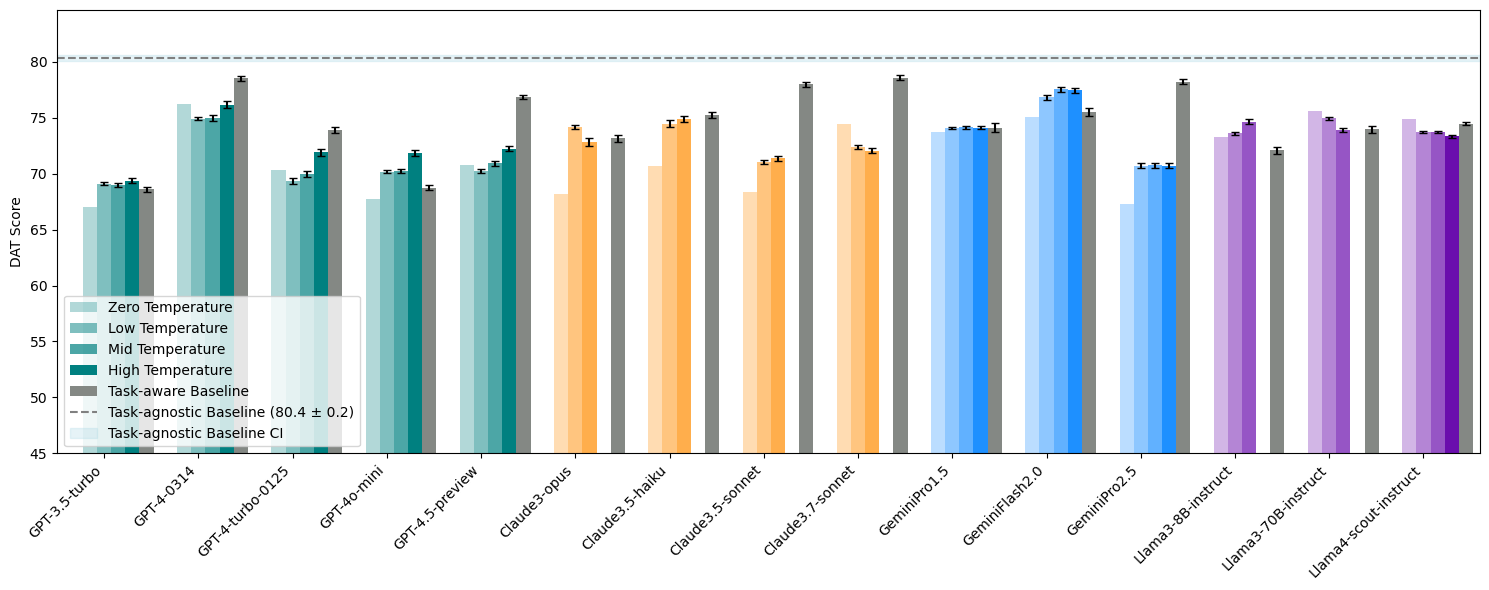

In [ ]:
# Configuration
confidence_level = 0.95
temps = ['Zero', 'Low', 'Mid', 'High', 'Control']

# Filter data to include only models in model_order
model_df = filtered_all_df[filtered_all_df['Model'].isin(model_order)]

# Compute mean / std / count
stats_df = (
    model_df
    .groupby(['Model', 'Temperature'])['SBERT score']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

# Compute confidence intervals
def calculate_ci(row):
    mean = row['mean']
    std = row['std']
    count = row['count']
    std_err = std / np.sqrt(count)
    ci = stats.t.interval(confidence_level, count - 1, loc=mean, scale=std_err)
    return pd.Series({
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'ci_error': (ci[1] - ci[0]) / 2
    })

ci_stats = stats_df.apply(calculate_ci, axis=1)
stats_df = pd.concat([stats_df, ci_stats], axis=1)

# Enforce model order
stats_df['Model'] = pd.Categorical(
    stats_df['Model'],
    categories=model_order,
    ordered=True
)
stats_df = stats_df.sort_values(['Model', 'Temperature'])

plt.figure(figsize=(15, 6))

num_models = len(model_order)
model_spacing = 1.0
x = np.arange(num_models) * model_spacing
width = 0.15

# Which models have High temperature
models_with_high = set(
    stats_df[stats_df['Temperature'] == 'High']['Model'].values
)

for i, temp in enumerate(temps):
    temp_data = stats_df[stats_df['Temperature'] == temp]

    if temp_data.empty:
        continue

    # Task-agnostic baseline (Control) 
    if temp == 'Control':
        positions, means, ci_errors = [], [], []

        for model in model_order:
            if model in temp_data['Model'].values:
                model_idx = model_order.index(model)
                control_position = x[model_idx] + 3 * width

                positions.append(control_position)
                row = temp_data[temp_data['Model'] == model].iloc[0]
                means.append(row['mean'])
                ci_errors.append(row['ci_error'])

        if positions:
            plt.bar(
                positions,
                means,
                width,
                yerr=ci_errors,
                capsize=3,
                label='Task-aware Baseline',
                color='#848884',
                alpha=1.0
            )

    # DAT temperatures
    else:
        for model_prefix, base_color in color_dict.items():
            if model_prefix == 'Control':
                continue

            mask = temp_data['Model'].str.startswith(model_prefix)
            if not mask.any():
                continue

            positions, means, ci_errors = [], [], []

            for model in model_order:
                if model in temp_data['Model'].values and model.startswith(model_prefix):
                    model_idx = model_order.index(model)
                    temp_position = x[model_idx] + (i - 1) * width

                    positions.append(temp_position)
                    row = temp_data[temp_data['Model'] == model].iloc[0]
                    means.append(row['mean'])
                    ci_errors.append(row['ci_error'])

            if positions:
                label = (
                    f'{temp} Temperature'
                    if model_prefix == list(color_dict.keys())[0]
                    else None
                )

                if temp == 'Zero':
                    plt.bar(
                        positions,
                        means,
                        width,
                        label=label,
                        color=base_color,
                        alpha=alpha_dict[temp]
                    )
                else:
                    plt.bar(
                        positions,
                        means,
                        width,
                        yerr=ci_errors,
                        capsize=3,
                        label=label,
                        color=base_color,
                        alpha=alpha_dict[temp]
                    )

# Baseline and CI band
x_min = min(x) - 0.5
x_max = max(x) + 4 * width

plt.axhline(
    y=sbert_baseline,
    color='gray',
    linestyle='--',
    label=f'Task-agnostic Baseline ({sbert_baseline:.1f} ± {sbert_baseline_ci:.1f})'
)

plt.fill_between(
    [x_min, x_max],
    sbert_baseline - sbert_baseline_ci,
    sbert_baseline + sbert_baseline_ci,
    color='lightblue',
    alpha=0.3,
    label='Task-agnostic Baseline CI'
)

plt.xlim(x_min, x_max)
plt.ylim(45, None)

plt.ylabel('DAT Score')
plt.xticks(x, model_order, rotation=45, ha='right')

handles, labels = plt.gca().get_legend_handles_labels()
temp_handles = [h for h, l in zip(handles, labels) if 'Temperature' in l or 'Task-aware' in l]
temp_labels = [l for l in labels if 'Temperature' in l or 'Task-aware' in l]

baseline_handles = [h for h, l in zip(handles, labels) if 'Task-agnostic' in l]
baseline_labels = [l for l in labels if 'Task-agnostic' in l]

temp_handles.extend(baseline_handles)
temp_labels.extend(baseline_labels)

plt.legend(temp_handles, temp_labels, loc='lower left')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'bert_scores_with_ci_and_control_v2.png', dpi=600, bbox_inches='tight')
plt.show()


### T-tests between the task-agnostic baseline and LLMs

In [ ]:
temps = ['Low', 'Mid', 'High']

# Perform t-tests for SBERT scores (Score column)
sbert_t_test_results = []

for model in model_order:
    for temp in temps:
        
        # Get SBERT scores for this model and temperature
        model_sbert_scores = results_df[(filtered_all_df['Model'] == model) & 
                                           (filtered_all_df['Temperature'] == temp)]['SBERT score'].dropna()

        if len(model_sbert_scores) > 0 and len(random_sbert_scores) > 0:
            # Perform t-test
            t_stat, p_val = stats.ttest_ind(model_sbert_scores, random_sbert_scores)
            
            sbert_t_test_results.append({
                'Model': model,
                'Temperature': temp,
                'p_value': p_val,
                't_statistic': t_stat,
                'model_mean': model_sbert_scores.mean(),
                'random_mean': random_sbert_scores.mean(),
                'model_std': model_sbert_scores.std(),
                'random_std': random_sbert_scores.std(),
                'model_n': len(model_sbert_scores),
                'random_n': len(random_sbert_scores)
            })
            
# Apply FDR correction for multiple comparisons
if sbert_t_test_results:
    sbert_p_values = [result['p_value'] for result in sbert_t_test_results]
    sbert_reject, sbert_p_corrected, _, _ = multipletests(
        sbert_p_values, 
        alpha=0.05, 
        method='fdr_bh'
    )
    
    for i, result in enumerate(sbert_t_test_results):
        sig = '***' if sbert_p_corrected[i] < 0.001 else '**' if sbert_p_corrected[i] < 0.01 else '*' if sbert_p_corrected[i] < 0.05 else 'ns'
        result['p_corrected'] = sbert_p_corrected[i]
        result['significant'] = sbert_reject[i]
        result['significance'] = sig

# Convert to DataFrames for easier analysis
sbert_df = pd.DataFrame(sbert_t_test_results)

# Display summary tables
if len(sbert_df) > 0:
    print("\nSBERT SCORES SUMMARY TABLE:")
    summary_sbert = sbert_df[['Model', 'Temperature', 't_statistic', 'p_value', 'p_corrected', 'significance']].copy()
    print(summary_sbert.to_string(index=False))


SBERT SCORES SUMMARY TABLE:
                Model Temperature  t_statistic       p_value   p_corrected significance
        GPT-3.5-turbo         Low   -79.058995  0.000000e+00  0.000000e+00          ***
        GPT-3.5-turbo         Mid   -73.197028  0.000000e+00  0.000000e+00          ***
        GPT-3.5-turbo        High   -66.271302  0.000000e+00  0.000000e+00          ***
           GPT-4-0314         Low   -37.128228 3.110992e-190 4.044289e-190          ***
           GPT-4-0314         Mid   -30.891915 1.378782e-147 1.629470e-147          ***
           GPT-4-0314        High   -22.388701  2.778001e-90  3.009501e-90          ***
     GPT-4-turbo-0125         Low   -61.110926  0.000000e+00  0.000000e+00          ***
     GPT-4-turbo-0125         Mid   -58.210940 3.952525e-323 1.531604e-322          ***
     GPT-4-turbo-0125        High   -44.214389 2.527718e-237 3.943241e-237          ***
          GPT-4o-mini         Low   -71.029916  0.000000e+00  0.000000e+00          ***
   

## Replication of GloVe Ranking

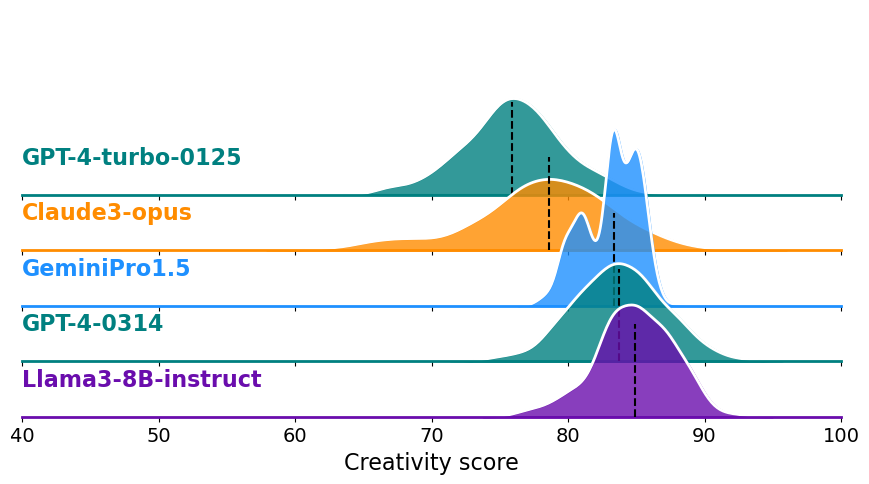

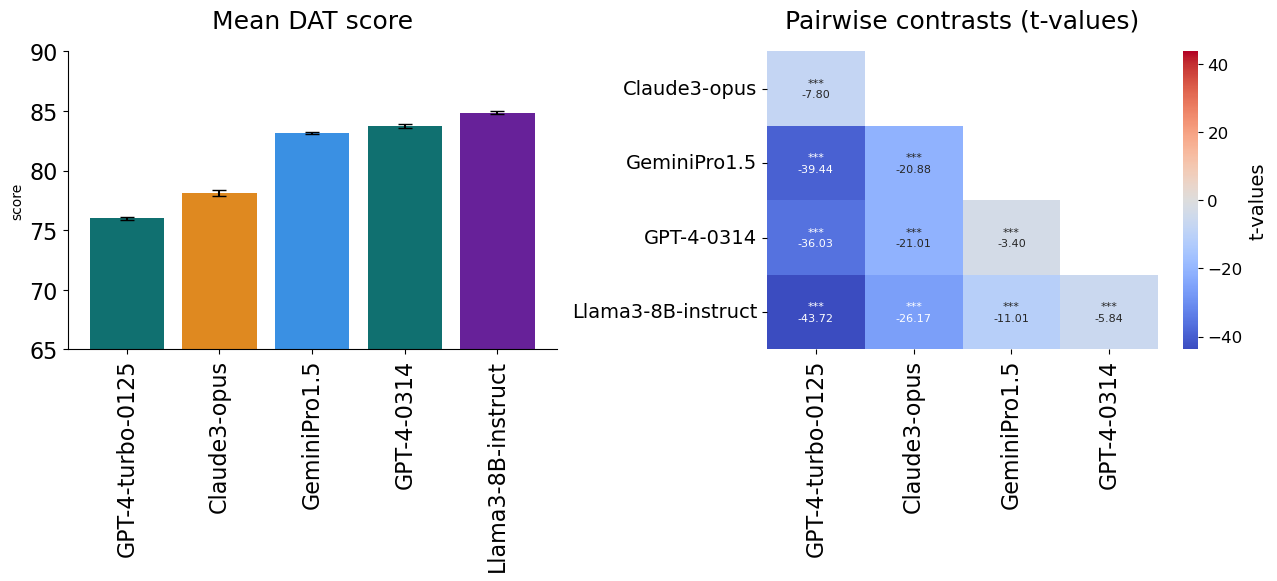

In [125]:
# Code adapted from https://github.com/AntoineBellemare/DAT_GPT/

# Initialize the FacetGrid object
pal = [
    colors['GPT-4-turbo-0125_mid_DAT'],
    colors['GPT-4-0314_mid_DAT'],
    colors['Claude3-opus_mid_DAT'],
    colors['GeminiPro1.5_mid_DAT'],
    colors['Llama3-8B-instruct_mid_DAT']
    ]

df = results_df.loc[
      (results_df['Strategy'] == 'DAT') &
      (results_df['Temperature'] == 'Mid')
]

models = [
      'Claude3-opus','GPT-4-turbo-0125', 'GPT-4-0314',
      'GeminiPro1.5', 'Llama3-8B-instruct'
]

df = df[df['Model'].isin(models)]

# Sort models by mean Glove score
order = df.groupby('Model')['Glove score'].mean().sort_values(ascending=True).index

# Create palette dictionary with original colors
color_dict = {model: colors[f'{model}_mid_DAT'] for model in models}

# Sort the palette based on the order
pal = [color_dict[model] for model in order]

# Remove outliers (>3 std) and sample up to cut_off
df = df.groupby('Model').apply(
      lambda x: x[np.abs(x['Glove score'] - x['Glove score'].mean()) <= 3 * x['Glove score'].std()]
).reset_index(drop=True)

df = df.groupby('Model').apply(
      lambda x: x.sample(min(len(x), cut_off), random_state=32)
).reset_index(drop=True)

# Initialize FacetGrid
g = sns.FacetGrid(
      df,
      row="Model",
      hue="Model",
      aspect=9,
      height=1,
      row_order=order,
      palette=pal,
      hue_order=order
)

# Make transparent background
for ax in g.axes.flat:
      ax.set_facecolor('none')

# Draw KDE plots
g.map(
      sns.kdeplot,
      "Glove score",
      bw_adjust=1,
      clip_on=False,
      fill=True,
      alpha=0.8,
      linewidth=1.5
)
g.map(
      sns.kdeplot,
      "Glove score",
      clip_on=False,
      color="w",
      lw=2,
      bw_adjust=1
)

# Passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Function to label axes
def label(x, color, label):
      ax = plt.gca()
      ax.text(
            0, .2, label,
            fontweight="bold",
            color=color,
            ha="left",
            va="center",
            transform=ax.transAxes,
            fontsize=16
      )

g.map(label, "Glove score")

# Analyze results
mean_conf, pvals, tvals, cohen_d = analyze_results(df, 'Model', order, metric='Glove score')

# Add vertical lines for mean
for ax, model in zip(g.axes.flat, order):
      ax.axvline(
            mean_conf[mean_conf['Model'] == model]['median'].values[0],
            color='black',
            linestyle='--',
            ymin=0,
            ymax=0.5
      )

# Adjust x-axis labels
for ax in g.axes.flat:
      ax.set_xlabel('Creativity score', fontsize=16)
      for label_tick in ax.get_xticklabels():
            label_tick.set_fontsize(14)

# Remove overlapping details
g.set_titles("")
g.figure.subplots_adjust(hspace=-.7)  # Reduce space between axes
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.set(xlim=(40, 100))

# Save KDE plot
g.savefig(FIGURE_PATH / 'DAT_distribution_replication.png', dpi=300)

# Create heatmap
create_heatmap(
      mean_conf,
      'Model',
      tvals_table=tvals,
      pvals_table=pvals,
      pal=pal,
      order=order,
      xlim=(65, 90),
      large=(13, 6),
      axis_name='score',
      save=FIGURE_PATH / 'DAT_ranking_replication'
)


## SBERT-based Ranking

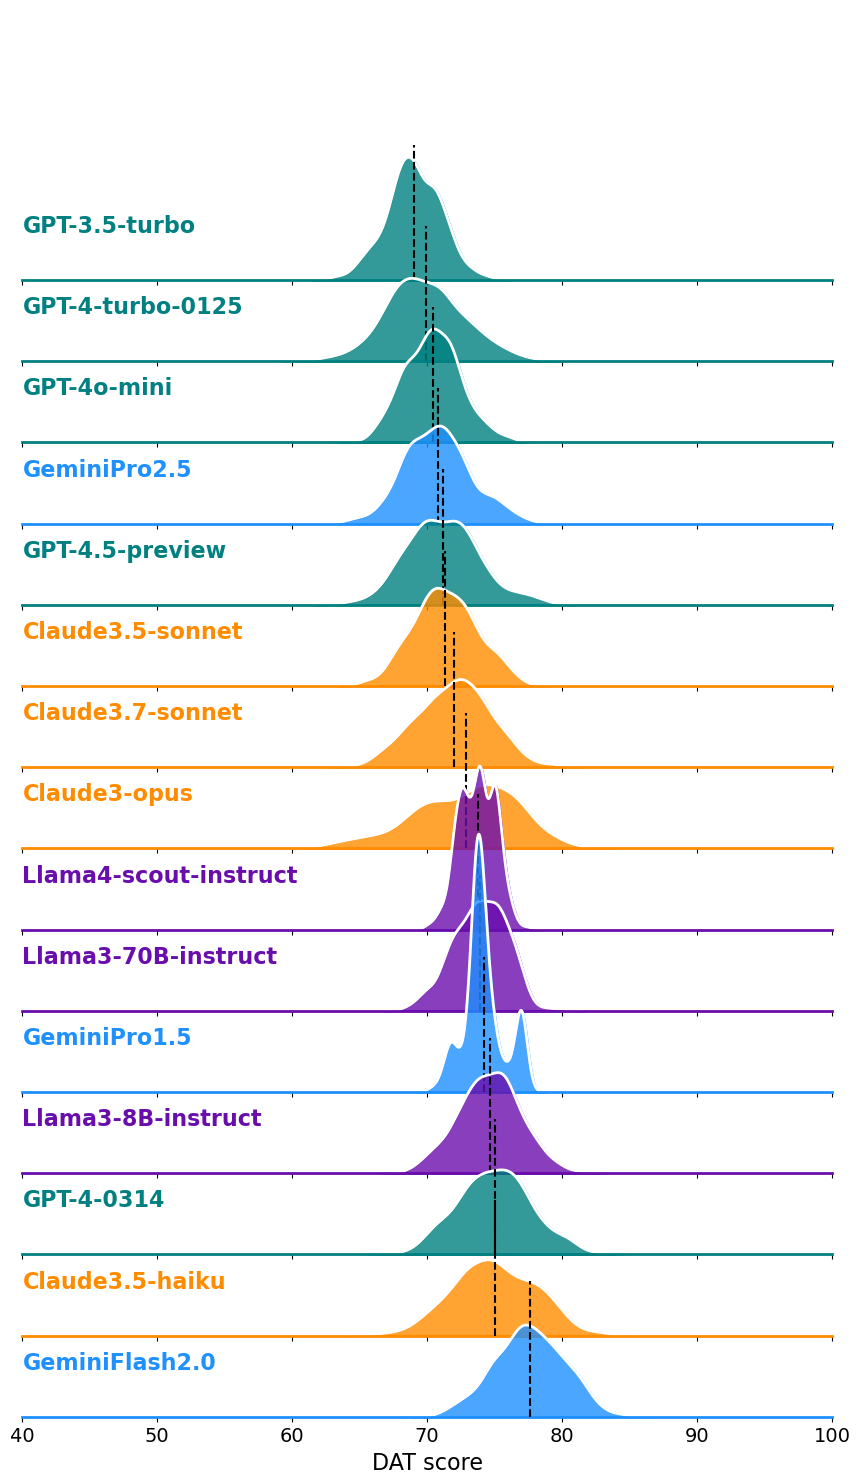

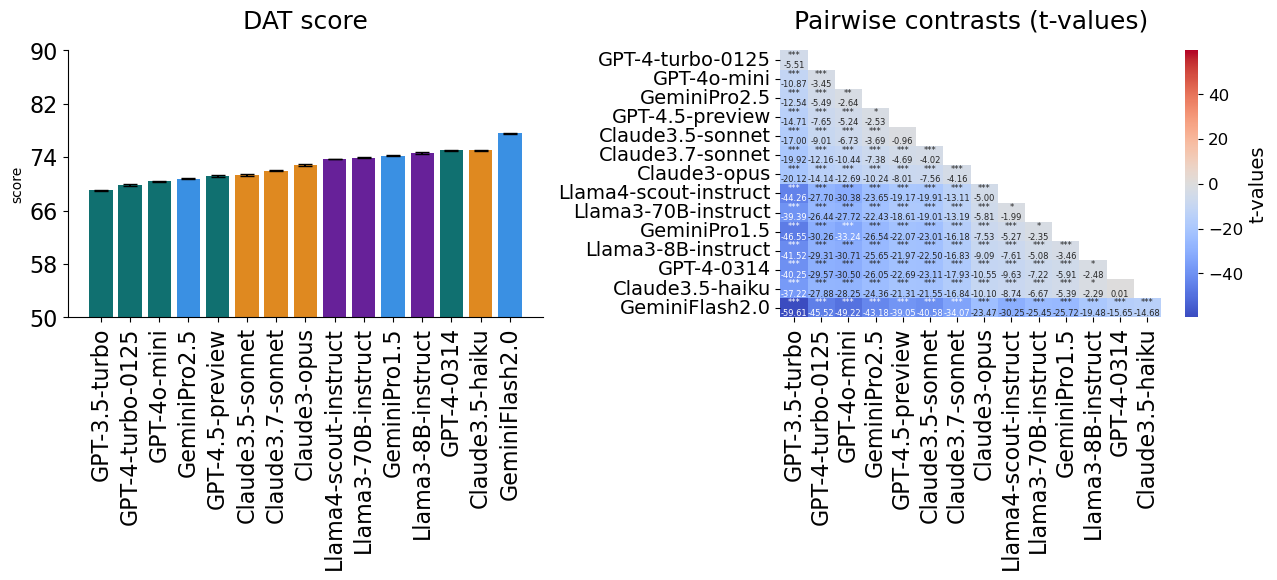

In [124]:
pal = [
    colors['GPT-4.5-preview_mid_DAT'],
    colors['GPT-4-turbo-0125_mid_DAT'],
    colors['GPT-4o-mini_mid_DAT'],
    colors['GPT-4-0314_mid_DAT'],
    colors['GPT-3.5-turbo_mid_DAT'],
    colors['Claude3.7-sonnet_mid_DAT'],
    colors['Claude3.5-sonnet_mid_DAT'],
    colors['Claude3.5-haiku_mid_DAT'],
    colors['Claude3-opus_mid_DAT'],
    colors['GeminiFlash2.0_mid_DAT'],
    colors['GeminiPro1.5_mid_DAT'],
    colors['GeminiPro2.5_mid_DAT'],
    colors['Llama3-8B-instruct_mid_DAT'],
    colors['Llama3-70B-instruct_mid_DAT'],
    colors['Llama4-scout-instruct_mid_DAT'],
    ]

df = results_df.loc[
      (results_df['Strategy'] == 'DAT') &
      (results_df['Temperature'] == 'Mid')
]

models = [
      'GPT-4.5-preview','GPT-4-turbo-0125','GPT-4o-mini', 'GPT-4-0314', 'GPT-3.5-turbo',
      'Claude3.7-sonnet', 'Claude3.5-sonnet', 'Claude3.5-haiku', 'Claude3-opus',
      'GeminiFlash2.0', 'GeminiPro1.5', 'GeminiPro2.5',
      'Llama3-8B-instruct', 'Llama3-70B-instruct', 'Llama4-scout-instruct'
]

df = df[df['Model'].isin(models)]

# Sort models by mean SBERT score
order = df.groupby('Model')['SBERT score'].mean().sort_values(ascending=True).index

# Create palette dictionary with original colors
color_dict = {model: colors[f'{model}_mid_DAT'] for model in models}

# Sort the palette based on the order
pal = [color_dict[model] for model in order]

# Remove outliers (>3 std) and sample up to cut_off
df = df.groupby('Model').apply(
      lambda x: x[np.abs(x['SBERT score'] - x['SBERT score'].mean()) <= 3 * x['SBERT score'].std()]
).reset_index(drop=True)

df = df.groupby('Model').apply(
      lambda x: x.sample(min(len(x), cut_off), random_state=32)
).reset_index(drop=True)

# Initialize FacetGrid
g = sns.FacetGrid(
      df,
      row="Model",
      hue="Model",
      aspect=9,
      height=1,
      row_order=order,
      palette=pal,
      hue_order=order
)

# Make transparent background
for ax in g.axes.flat:
      ax.set_facecolor('none')

# Draw KDE plots
g.map(
      sns.kdeplot,
      "SBERT score",
      bw_adjust=1,
      clip_on=False,
      fill=True,
      alpha=0.8,
      linewidth=1.5
)
g.map(
      sns.kdeplot,
      "SBERT score",
      clip_on=False,
      color="w",
      lw=2,
      bw_adjust=1
)

# Passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Function to label axes
def label(x, color, label):
      ax = plt.gca()
      ax.text(
            0, .2, label,
            fontweight="bold",
            color=color,
            ha="left",
            va="center",
            transform=ax.transAxes,
            fontsize=16
      )

g.map(label, "SBERT score")

# Analyze results
mean_conf, pvals, tvals, cohen_d = analyze_results(df, 'Model', order, metric='SBERT score')

# Add vertical lines for mean
for ax, model in zip(g.axes.flat, order):
      ax.axvline(
            mean_conf[mean_conf['Model'] == model]['mean'].values[0],
            color='black',
            linestyle='--',
            ymin=0,
            ymax=0.5
      )

# Adjust x-axis labels
for ax in g.axes.flat:
      ax.set_xlabel('DAT score', fontsize=16)
      for label_tick in ax.get_xticklabels():
            label_tick.set_fontsize(14)

# Remove overlapping details
g.set_titles("")
g.figure.subplots_adjust(hspace=-.7)  # Reduce space between axes
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.set(xlim=(40, 100))

# Save KDE plot
g.savefig(FIGURE_PATH / 'DAT_distribution.png', dpi=300, bbox_inches='tight')

# Create heatmap
create_heatmap(
      mean_conf,
      'Model',
      tvals_table=tvals,
      pvals_table=pvals,
      pal=pal,
      order=order,
      xlim=(50, 90),
      large=(13, 6),
      axis_name='score',
      title_name='DAT score',
      annot_fontsize=6,
      save=FIGURE_PATH / 'overal_ranking'
)


## Temperature effects for each model

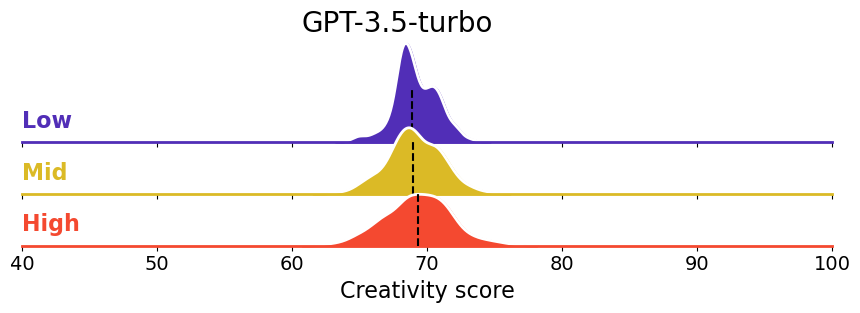

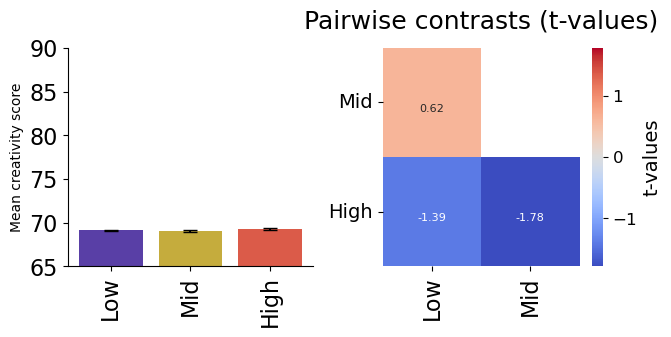

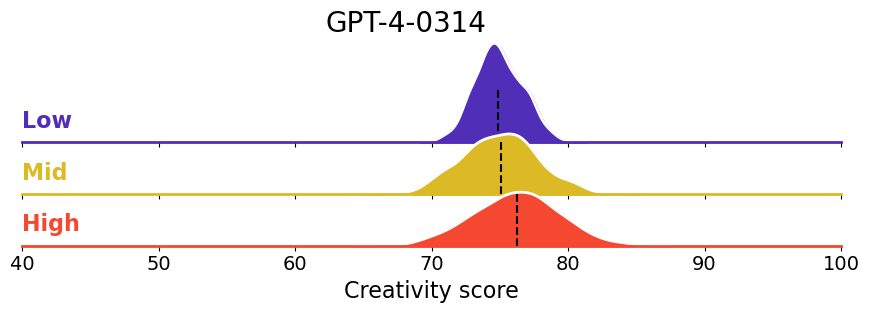

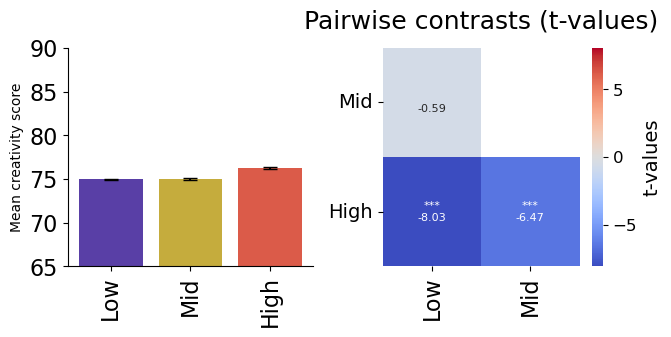

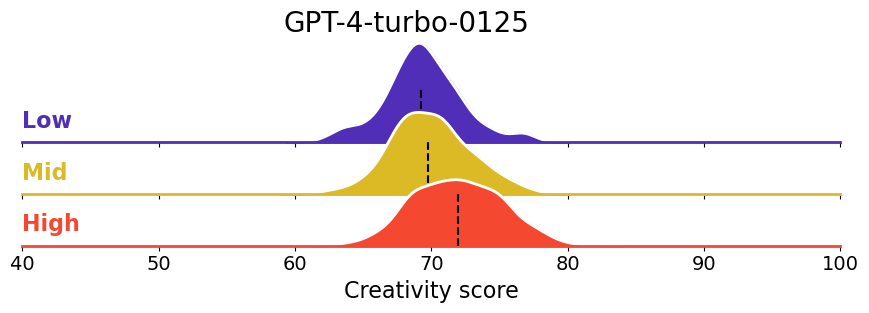

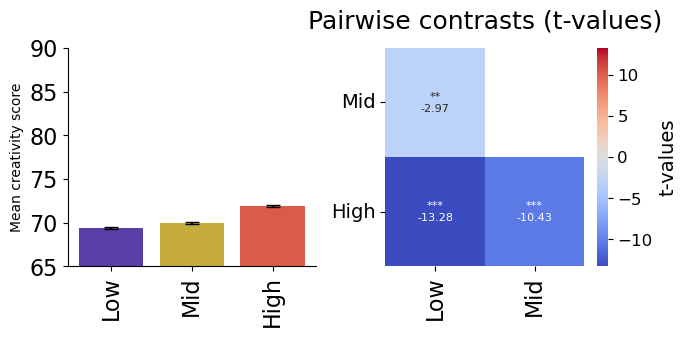

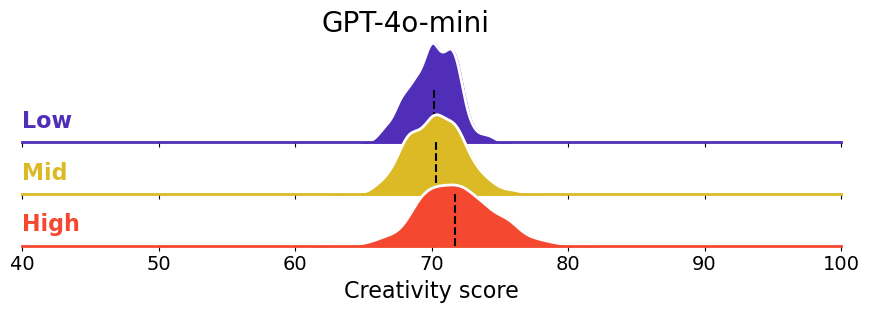

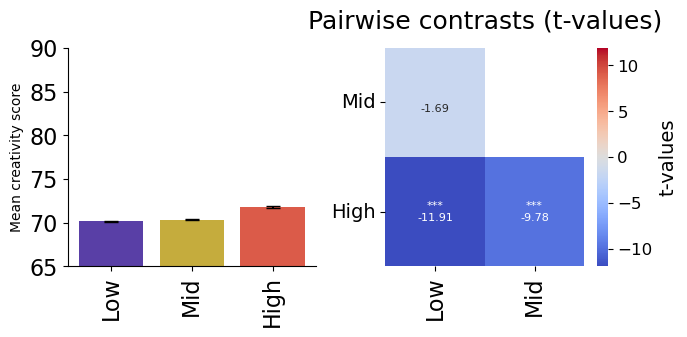

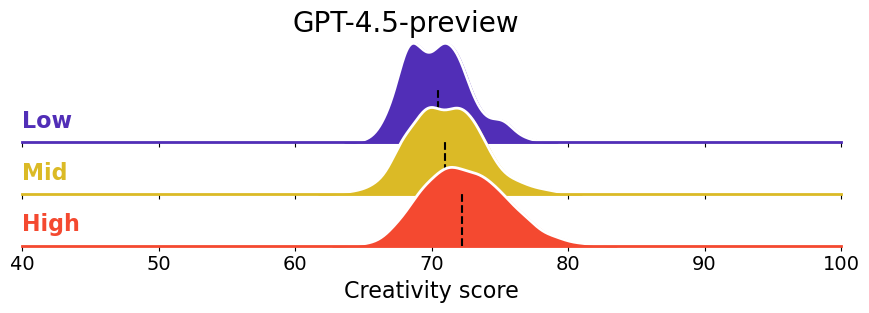

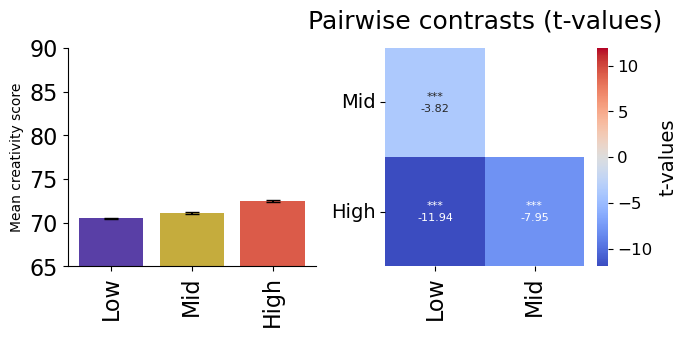

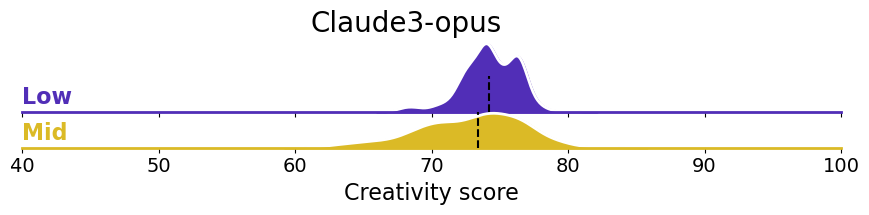

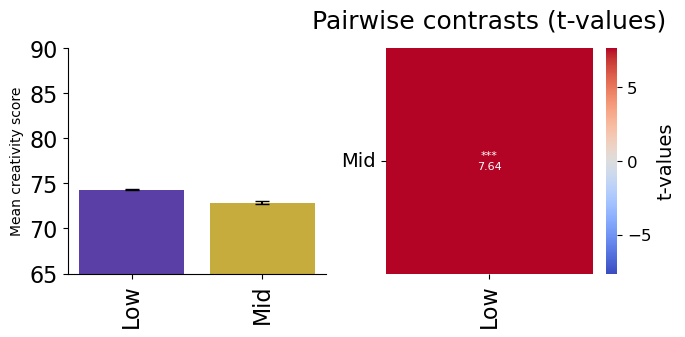

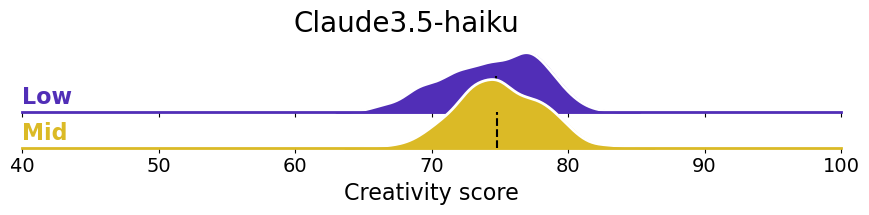

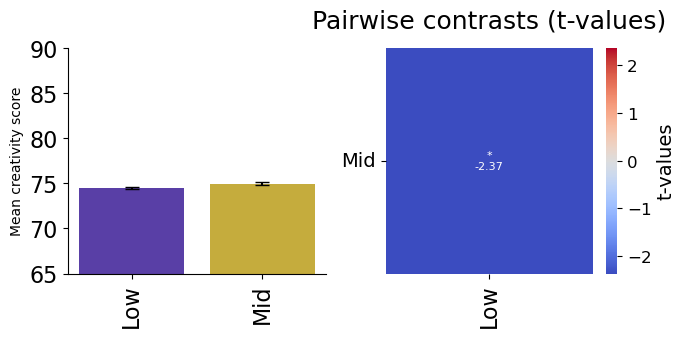

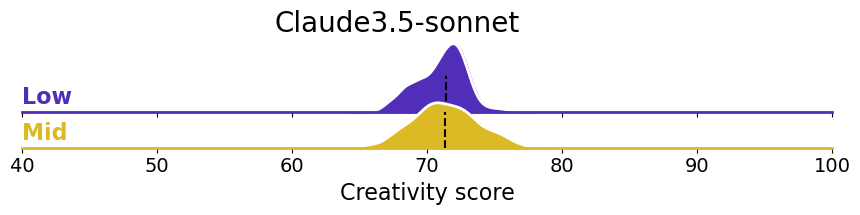

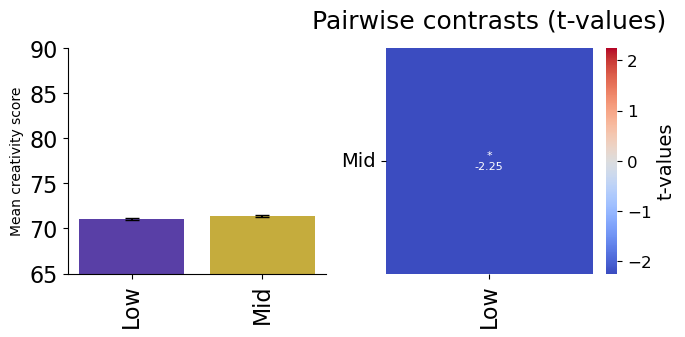

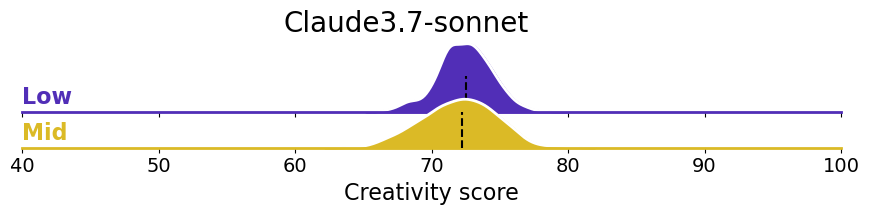

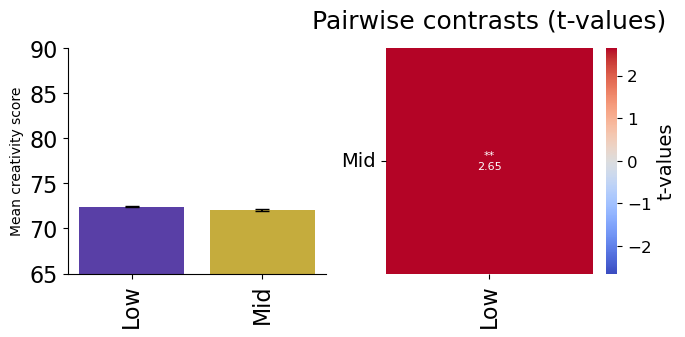

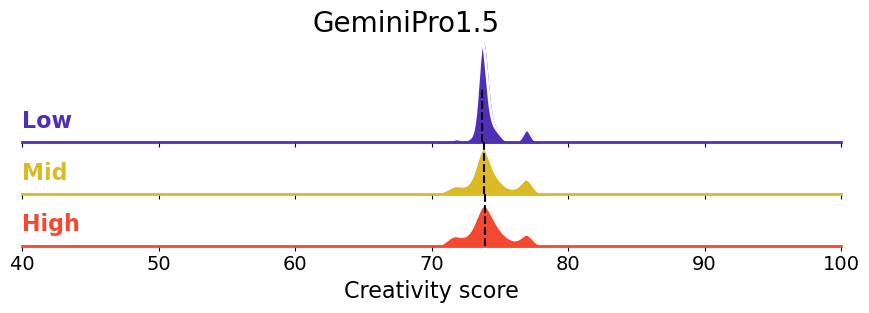

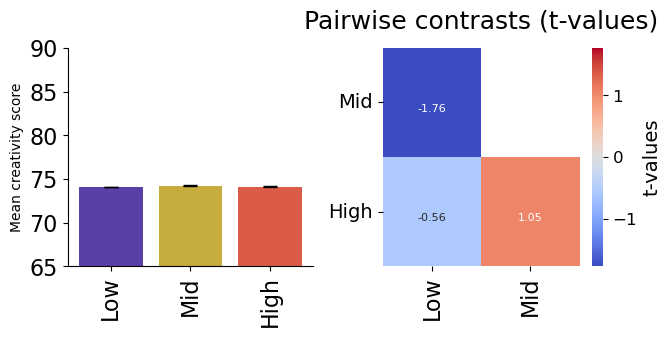

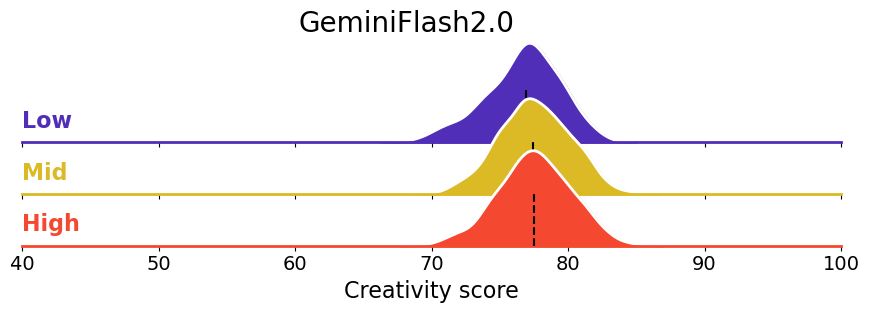

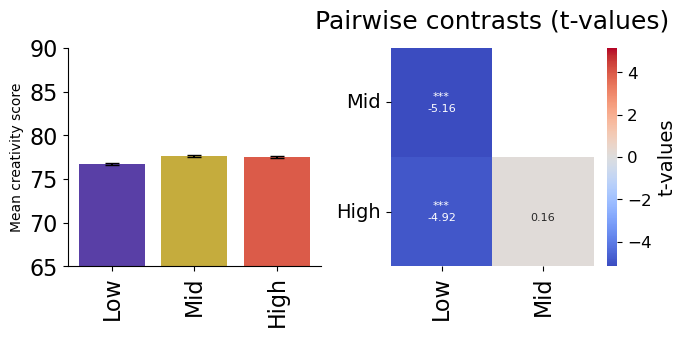

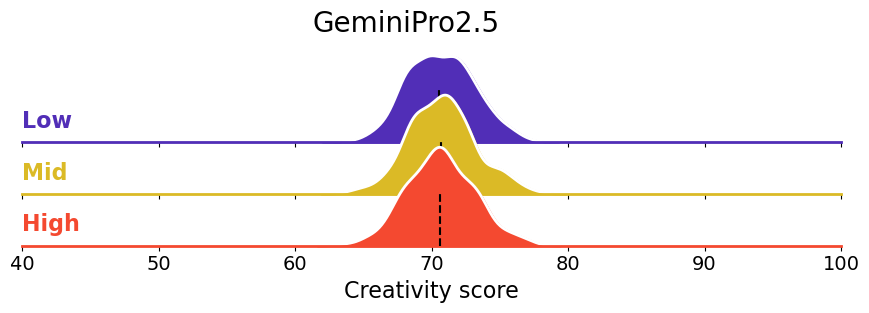

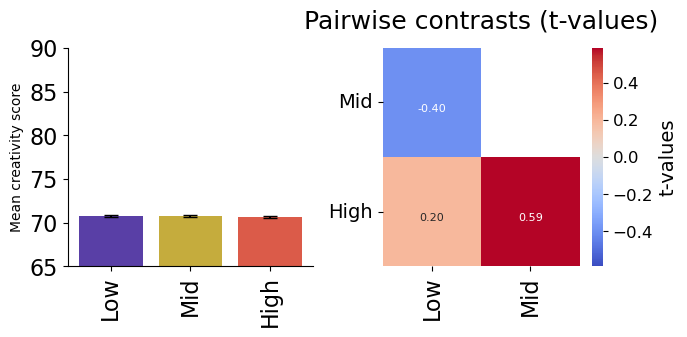

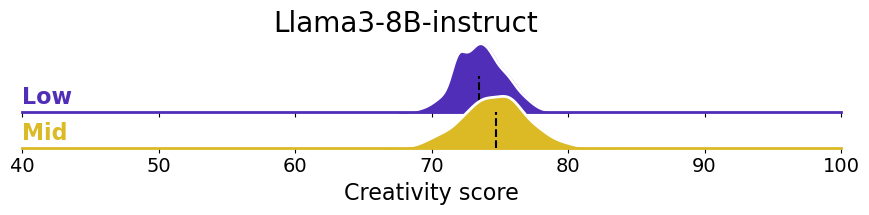

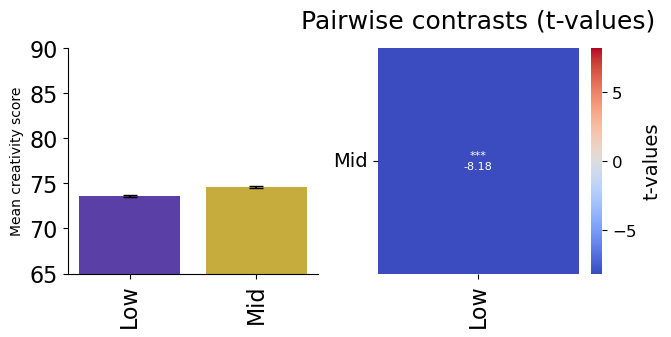

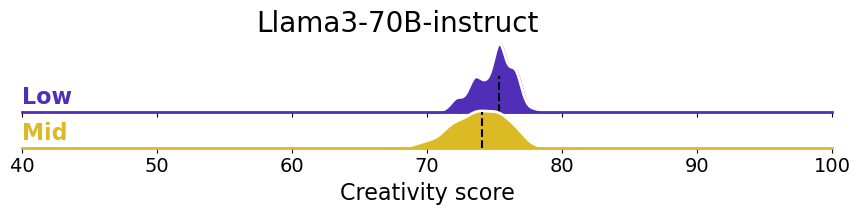

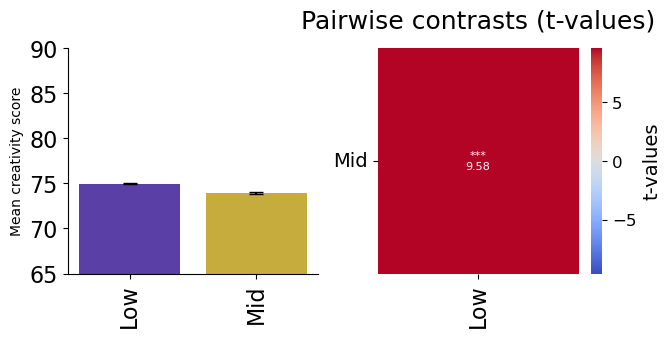

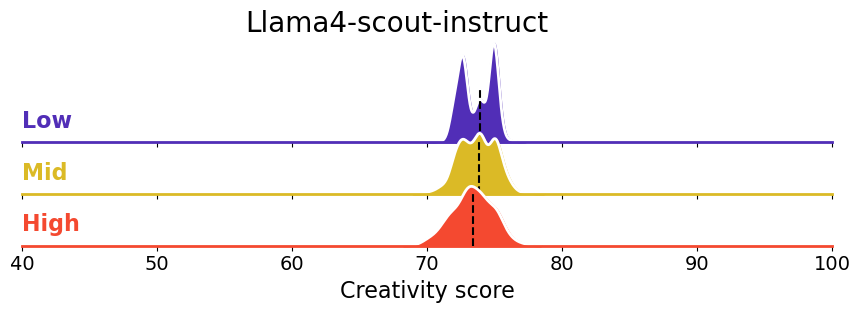

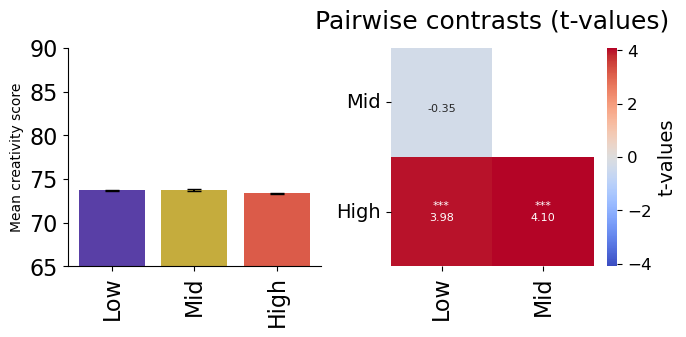

In [ ]:
# Code adapted from https://github.com/AntoineBellemare/DAT_GPT/

temp_models = [
      "GPT-3.5-turbo", "GPT-4-0314", "GPT-4-turbo-0125", "GPT-4o-mini", "GPT-4.5-preview",
      "Claude3-opus", "Claude3.5-haiku", "Claude3.5-sonnet", "Claude3.7-sonnet",
      "GeminiPro1.5", "GeminiFlash2.0", "GeminiPro2.5",
      "Llama3-8B-instruct", "Llama3-70B-instruct", "Llama4-scout-instruct"
]

for model in temp_models:

      # Select DAT-only data for this model
      df = results_df[(results_df['Model'] == model) &
                      (results_df['Strategy'] == 'DAT')].copy()

      # Define temperature conditions
      if 'Claude' in model or 'Llama3' in model:
            conditions = ['Low', 'Mid']
      else:
            conditions = ['Low', 'Mid', 'High']

      # Remove observations with more or less than 3 std per temperature
      df = df.groupby('Temperature').apply(
            lambda x: x[np.abs(x['SBERT score'] - x['SBERT score'].mean()) <=
                        3 * x['SBERT score'].std()]
      ).reset_index(drop=True)

      # Randomly sample up to cutoff per temperature
      df = df.groupby('Temperature').apply(
            lambda x: x.sample(min(len(x), cut_off), random_state=42)
      ).reset_index(drop=True)

      # Initialize the FacetGrid object
      pal = sns.color_palette('CMRmap', n_colors=3, desat=.9)
      pal = [pal[0], pal[2], pal[1]]

      g = sns.FacetGrid(
            df,
            row="Temperature",
            hue="Temperature",
            aspect=9,
            height=1,
            palette=pal,
            row_order=conditions,
            hue_order=conditions
      )

      # Make transparent background
      for ax in g.axes.flat:
            ax.set_facecolor('none')

      # Draw the densities
      g.map(
            sns.kdeplot,
            "SBERT score",
            bw_adjust=1,
            clip_on=False,
            fill=True,
            alpha=1,
            linewidth=1.5
      )
      g.map(
            sns.kdeplot,
            "SBERT score",
            clip_on=False,
            color="w",
            lw=2,
            bw_adjust=1
      )

      g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

      # Label rows
      for ax, temp, color in zip(g.axes.flat, conditions, pal):
            ax.set_xlabel('Creativity score', fontsize=16)
            ax.text(
                  0, .2, temp,
                  fontweight="bold",
                  color=color,
                  ha="left",
                  va="center",
                  transform=ax.transAxes,
                  fontsize=16
            )
            for tick in ax.get_xticklabels():
                  tick.set_fontsize(14)

      # Statistical analysis
      mean_conf, pvals, tvals, cohen_d = analyze_results(
            df,
            'Temperature',
            order=conditions,
            metric="SBERT score"
      )

      # Add vertical median lines
      for ax, temp in zip(g.axes.flat, conditions):
            ax.axvline(
                  mean_conf[mean_conf['Temperature'] == temp]['median'].values[0],
                  color='black',
                  linestyle='--',
                  ymin=0,
                  ymax=0.5
            )

      # Layout cleanup
      g.figure.subplots_adjust(hspace=-.50)
      g.set_titles("")
      g.set(yticks=[], ylabel="")
      g.despine(bottom=True, left=True)
      g.set(xlim=(40, 100))

      # Save figures
      g.fig.suptitle(model, fontsize=20)
      g.savefig(
            FIGURE_PATH / f'{model}_DAT_temperature_dist_SBERT.png',
            dpi=300
      )

      create_heatmap(
            mean_conf,
            'Temperature',
            tvals_table=tvals,
            pvals_table=pvals,
            pal=pal,
            order=conditions,
            large=(7, 3.5),
            xlim=(65, 90),
            axis_name='Mean creativity score',
            title_name="",
            save=FIGURE_PATH / f'{model}_DAT_temperature_heatmap_SBERT.png'
      )


## DAT vs Task-Aware Baseline

In [ ]:
# Code adapted from https://github.com/AntoineBellemare/DAT_GPT/

temp_models = [
        "GPT-3.5-turbo", "GPT-4-0314", "GPT-4-turbo-0125", "GPT-4o-mini", "GPT-4.5-preview",
        "Claude3-opus", "Claude3.5-haiku", "Claude3.5-sonnet", "Claude3.7-sonnet",
        "GeminiPro1.5", "GeminiFlash2.0", "GeminiPro2.5", 
        "Llama3-8B-instruct", "Llama3-70B-instruct", "Llama4-scout-instruct"
    ]
    
results_df.loc[results_df['Strategy'] == 'Control', 'Temperature'] = 'Mid' # Task-aware baseline

list_of_dfs = [results_df.loc[(results_df['Model']=='GPT-4.5-preview') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GPT-4-turbo-0125') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GPT-4o-mini') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GPT-4-0314') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GPT-3.5-turbo') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Claude3.5-haiku') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Claude3-opus') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Claude3.7-sonnet') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Claude3.5-sonnet') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GeminiPro1.5') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GeminiFlash2.0') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='GeminiPro2.5') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Llama3-8B-instruct') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Llama3-70B-instruct') &
                              (results_df['Temperature']=='Mid')],
               results_df.loc[(results_df['Model']=='Llama4-scout-instruct') &
                              (results_df['Temperature']=='Mid')],
            ]



GPT-4.5-preview
Strategy
Control    500
DAT        500
dtype: int64


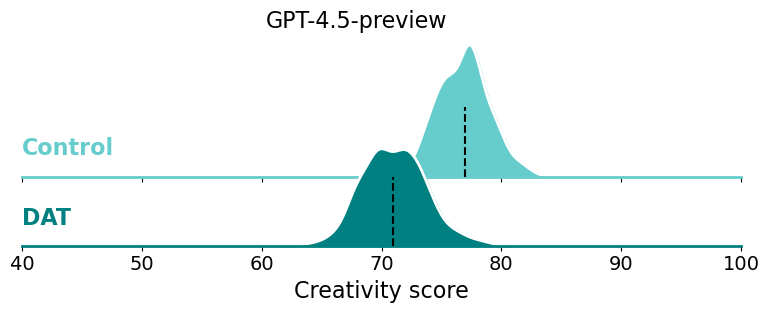

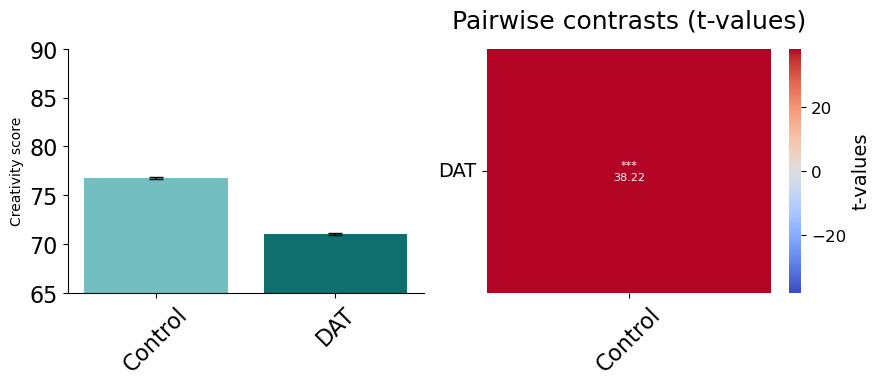


GPT-4-turbo-0125
Strategy
Control    500
DAT        500
dtype: int64


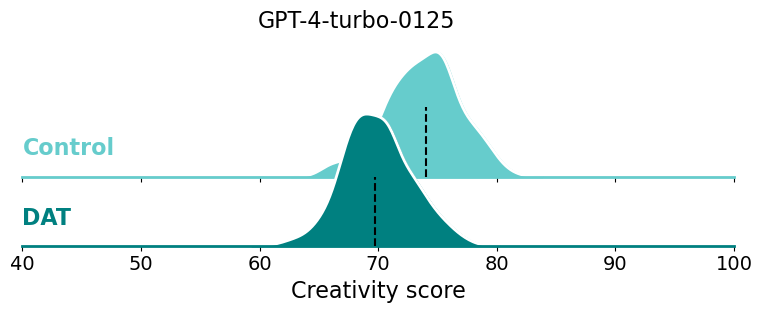

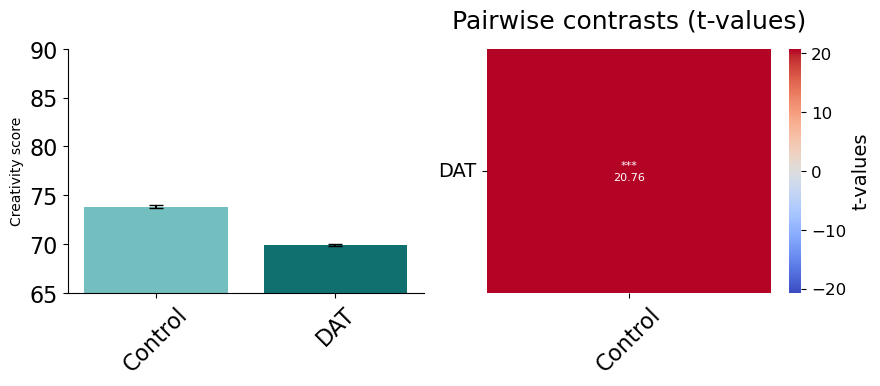


GPT-4o-mini
Strategy
Control    500
DAT        500
dtype: int64


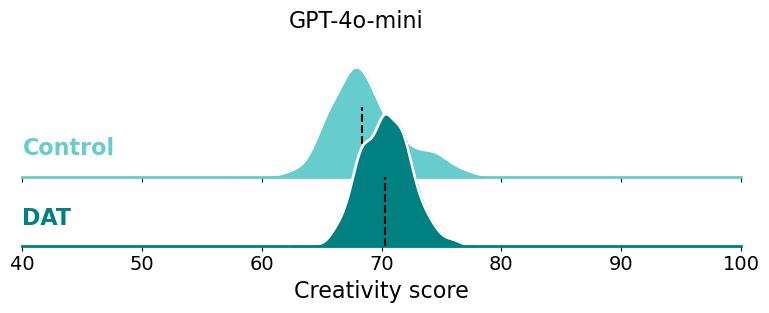

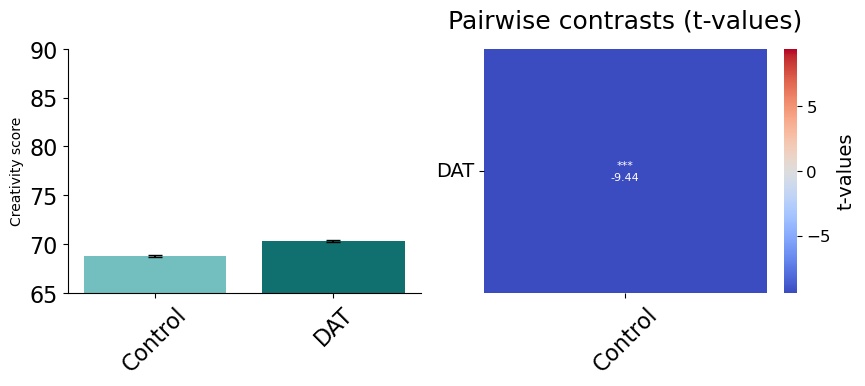


GPT-4-0314
Strategy
Control    500
DAT        500
dtype: int64


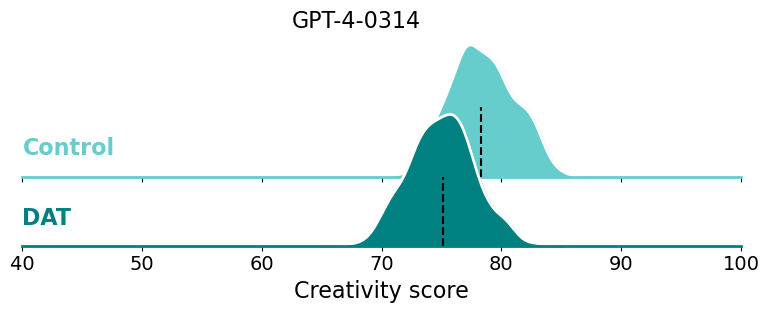

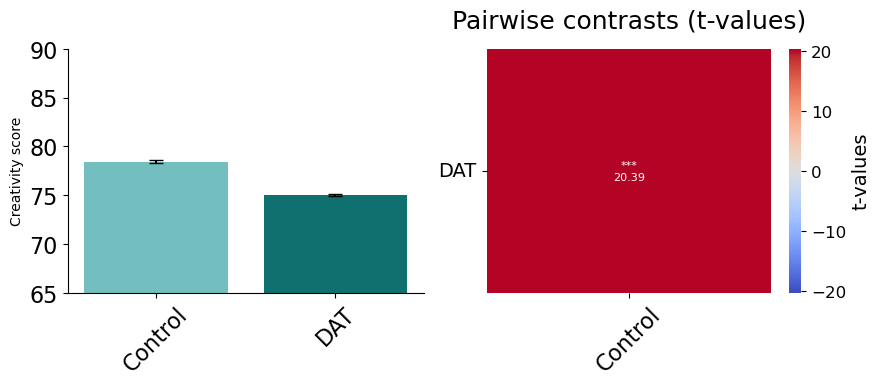


GPT-3.5-turbo
Strategy
Control    500
DAT        500
dtype: int64


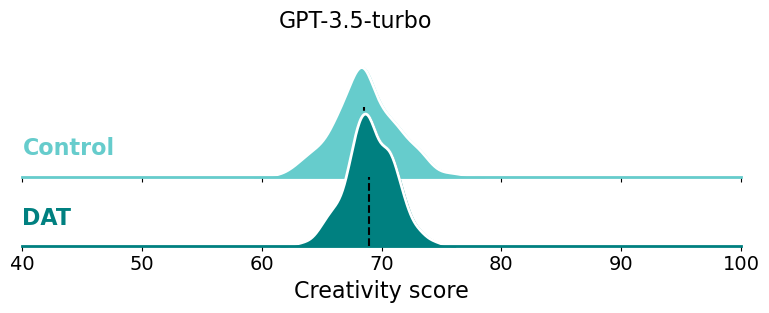

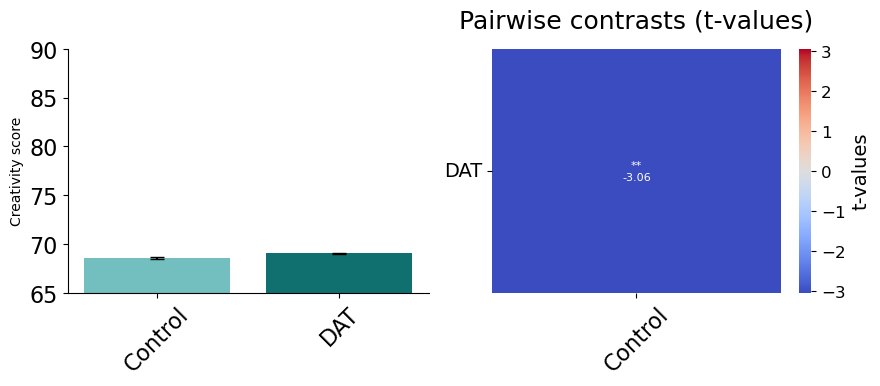


Claude3.5-haiku
Strategy
Control    500
DAT        500
dtype: int64


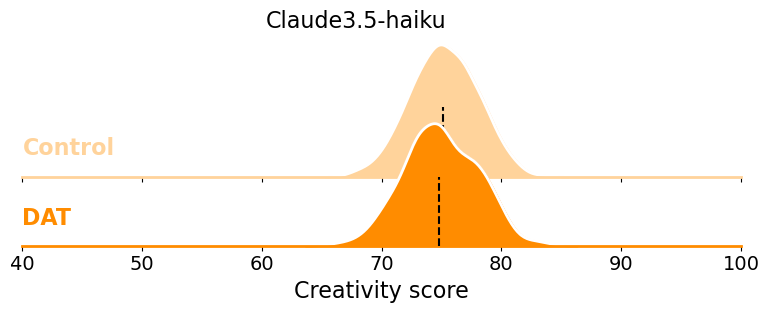

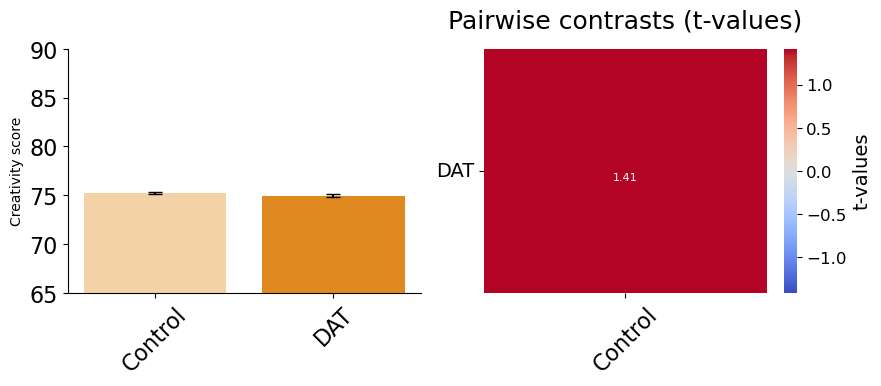


Claude3-opus
Strategy
Control    500
DAT        500
dtype: int64


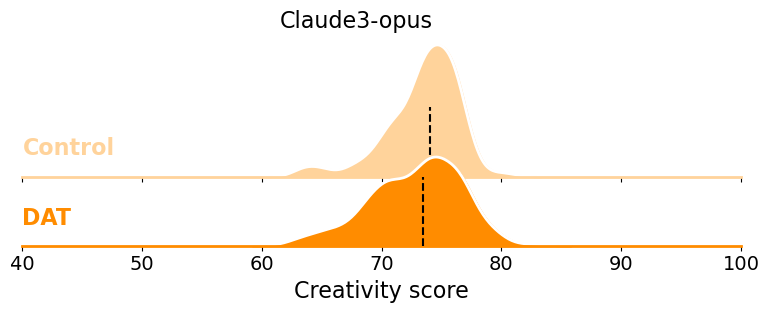

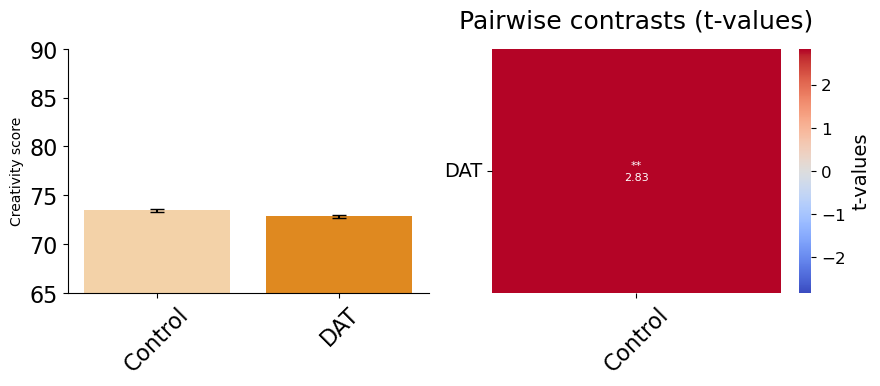


Claude3.7-sonnet
Strategy
Control    500
DAT        500
dtype: int64


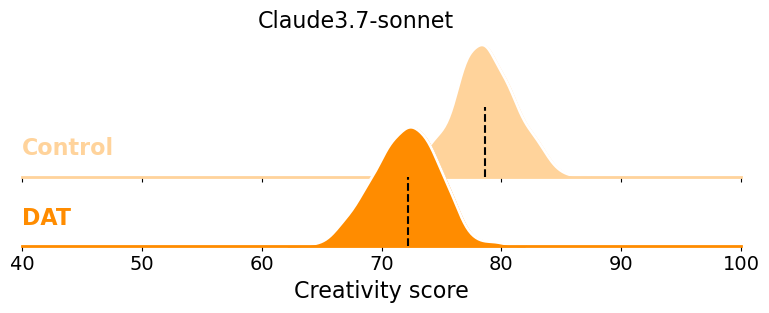

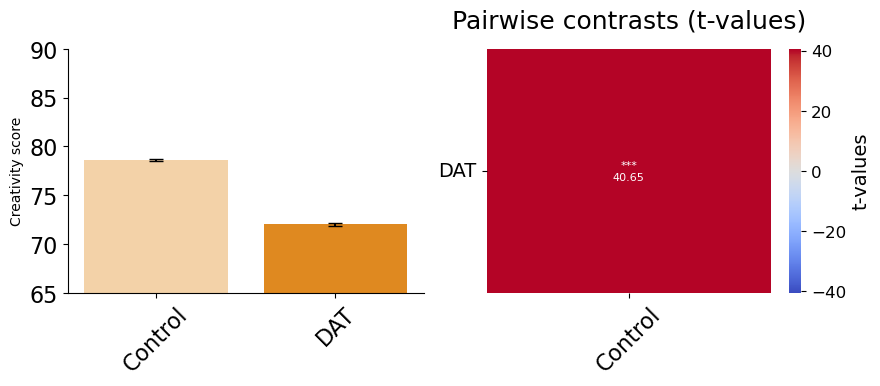


Claude3.5-sonnet
Strategy
Control    500
DAT        500
dtype: int64


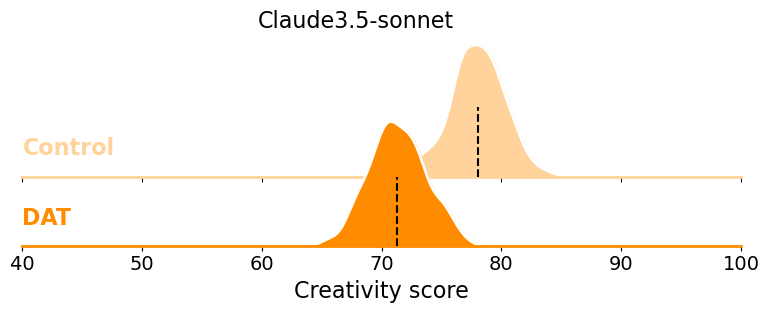

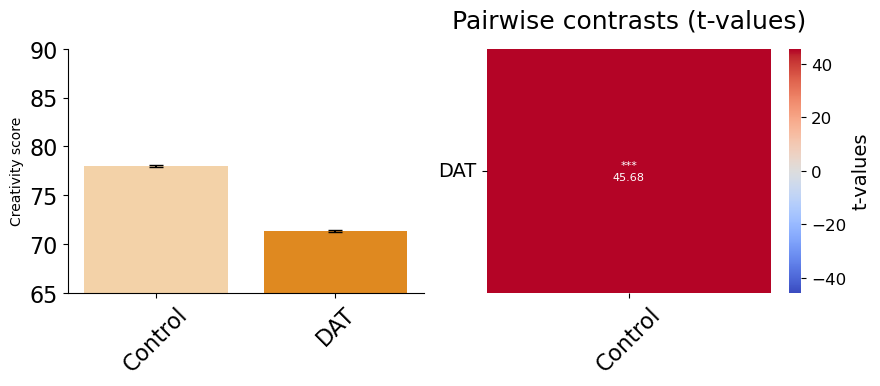


GeminiPro1.5
Strategy
Control    500
DAT        500
dtype: int64


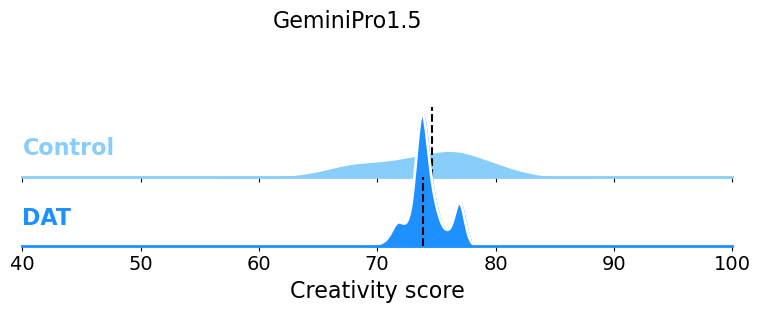

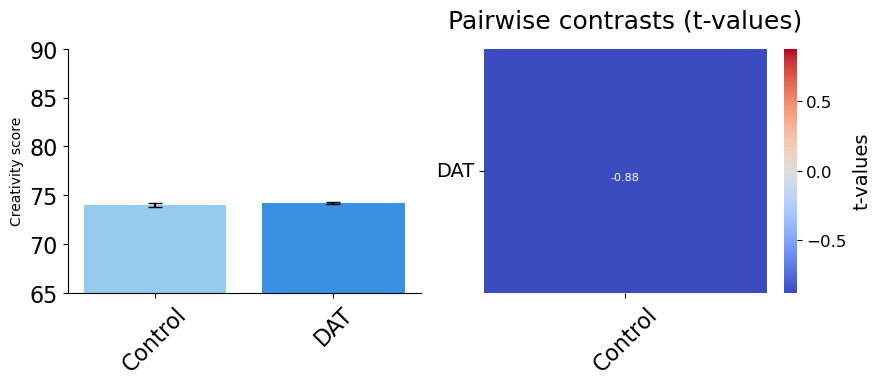


GeminiFlash2.0
Strategy
Control    500
DAT        500
dtype: int64


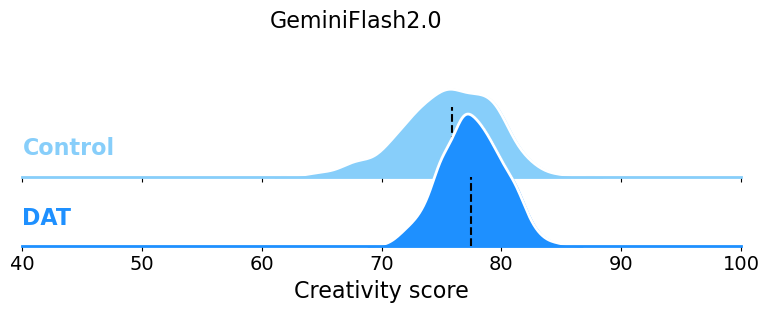

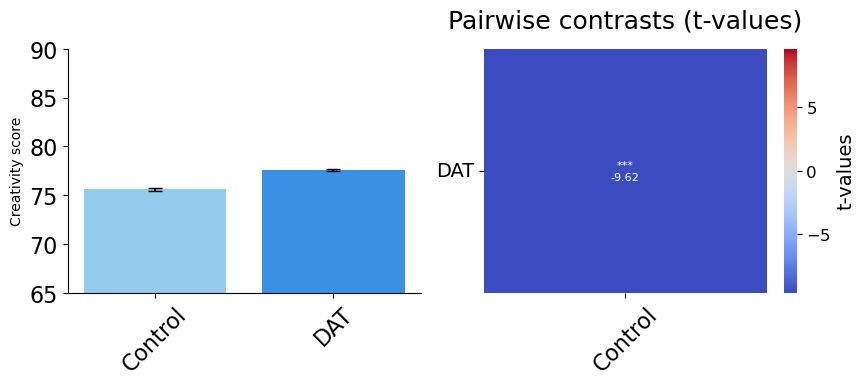


GeminiPro2.5
Strategy
Control    500
DAT        500
dtype: int64


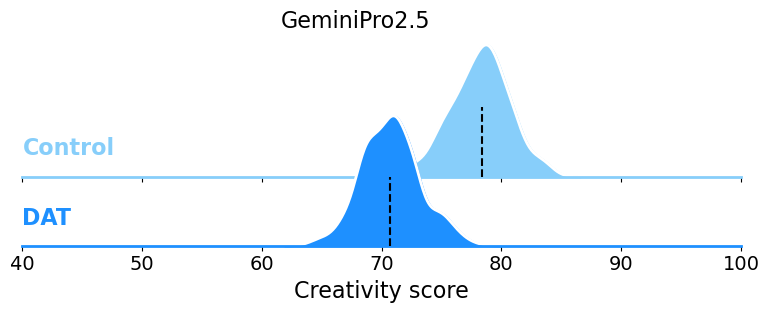

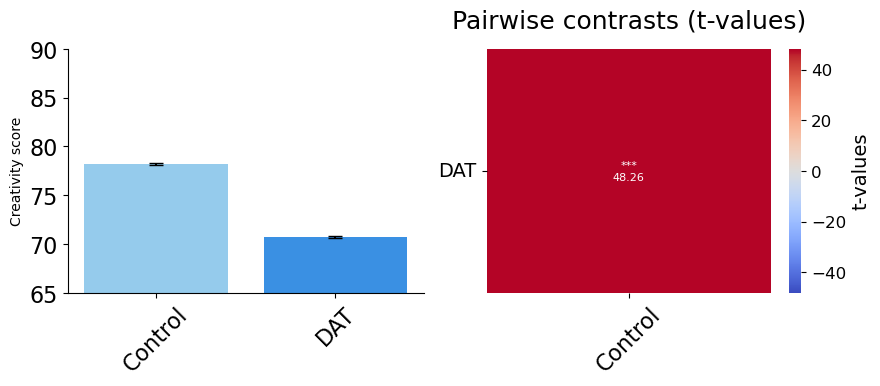


Llama3-8B-instruct
Strategy
Control    412
DAT        500
dtype: int64


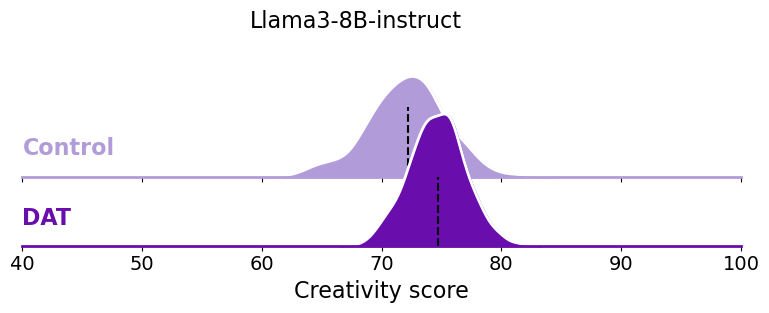

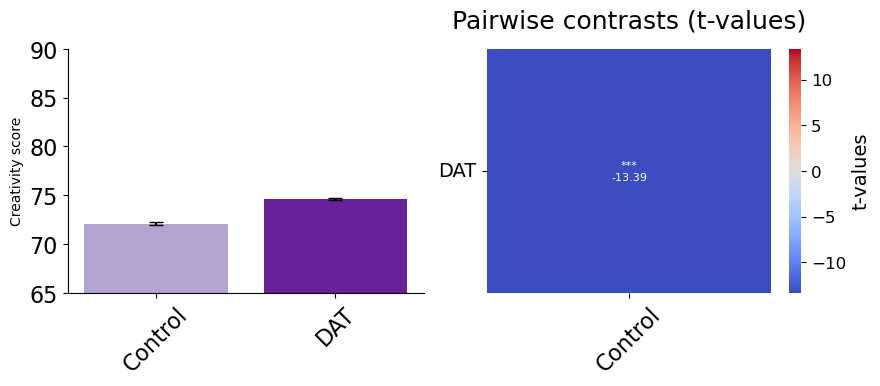


Llama3-70B-instruct
Strategy
Control    438
DAT        496
dtype: int64


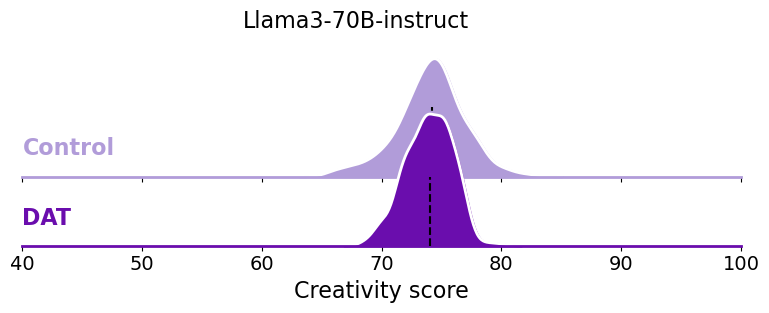

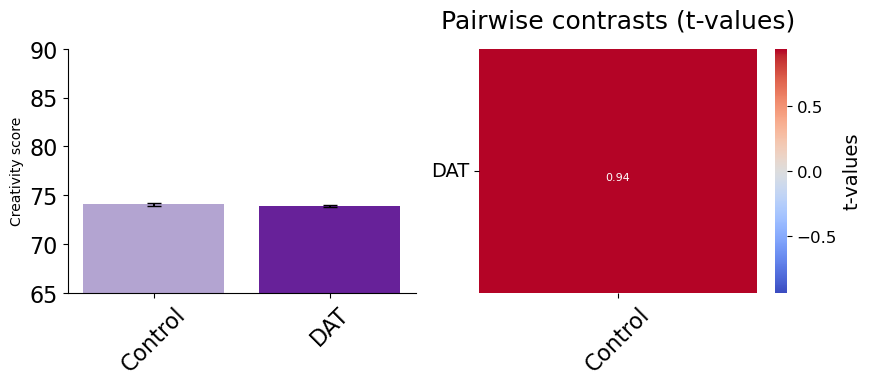


Llama4-scout-instruct
Strategy
Control    485
DAT        500
dtype: int64


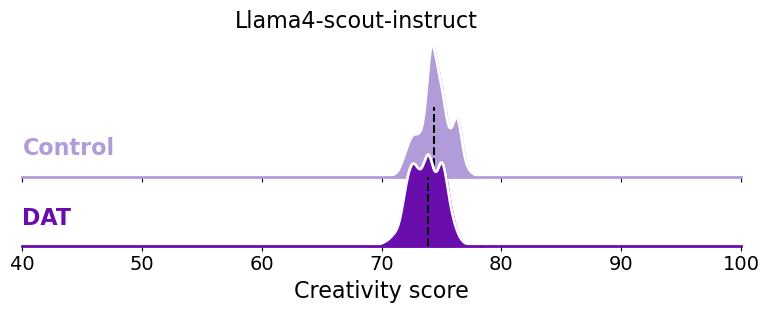

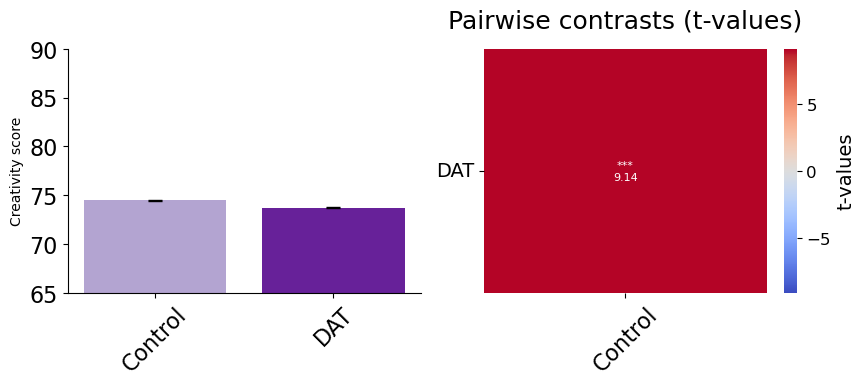

In [123]:
for e, df in enumerate(list_of_dfs):
      gpt = df["Model"].unique()[0]

      # Remove observations with more or less than 3 std, and then randomly sample up to 500 observations
      df = df.groupby('Strategy').apply(
            lambda x: x[np.abs(x['SBERT score'] - x['SBERT score'].mean()) <=
                        3 * x['SBERT score'].std()]
      ).reset_index(drop=True)

      df = df.groupby('Strategy').apply(
            lambda x: x.sample(min(len(x), cut_off), random_state=42)
      ).reset_index(drop=True)

      print(f"\n{gpt}")
      print(df.groupby('Strategy').size())

      # Initialize the FacetGrid object
      pal = [colors[f'{gpt}_mid_DAT'], colors[f'{gpt}_mid_control']]
      order = ['Control', 'DAT']

      g = sns.FacetGrid(
            df,
            row="Strategy",
            hue="Strategy",
            aspect=9,
            height=1,
            palette=[pal[1], pal[0]],
            row_order=order
      )

      # Set figure size
      g.fig.set_size_inches(8, 3)

      # Make transparent background
      for ax in g.axes.flat:
            ax.set_facecolor('none')

      # Draw the densities in a few steps
      g.map(
            sns.kdeplot,
            "SBERT score",
            bw_adjust=1,
            clip_on=False,
            fill=True,
            alpha=1,
            linewidth=1.5
      )
      g.map(
            sns.kdeplot,
            "SBERT score",
            clip_on=False,
            color="w",
            lw=2,
            bw_adjust=1
      )

      # Passing color=None to refline() uses the hue mapping
      g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

      # Define and use a simple function to label the plot in axes coordinates
      def label(x, color, label):
            ax = plt.gca()
            txt = f"{label}"
            ax.text(
                  0, .2, txt,
                  fontweight="bold",
                  color=color,
                  ha="left",
                  va="center",
                  transform=ax.transAxes,
                  fontsize=16
            )

      g.map(label, "SBERT score")

      # Increase title size
      g.set_titles(fontsize=16)

      mean_conf, pvals, tvals, cohen_d = analyze_results(
            df,
            'Strategy',
            order=order,
            metric="SBERT score"
      )

      # Add vertical lines for median
      for ax, model in zip(g.axes.flat, [0, 1]):
            ax.axvline(
                  mean_conf['median'][model],
                  color='black',
                  linestyle='--',
                  ymin=0,
                  ymax=0.5
            )

      # Set the subplots to overlap
      for ax in g.axes.flat:
            ax.set_xlabel('Creativity score', fontsize=16)
            for tick in ax.get_xticklabels():
                  tick.set_fontsize(14)

      g.figure.subplots_adjust(hspace=-.50)

      # Remove axes details that don't play well with overlap
      g.set_titles("")
      g.set(yticks=[], ylabel="")
      g.despine(bottom=True, left=True)
      g.set(xlim=(40, 100))

      g.fig.suptitle(gpt, fontsize=16)
      g.savefig(
            FIGURE_PATH / f'{gpt}_DAT_control_dist.png',
            dpi=300
      )

      create_heatmap(
            mean_conf,
            'Strategy',
            tvals_table=tvals,
            pvals_table=pvals,
            pal=reversed(pal),
            order=['Control', 'DAT'],
            large=(9, 4),
            xlim=(65, 90),
            rotation=45,
            axis_name='Creativity score',
            title_name="",
            save=FIGURE_PATH / f'{gpt}_DAT_control_heatmap.png'
      )
